# Studying The Geometry of Toy Model

In [103]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from typing import Tuple, List, Dict, Any, Union, Optional


## 1

In [104]:
def build_activations(D: int, F: int, alpha : float, C : float) -> torch.Tensor:
    # take default numpy rng
    probs = np.arange(1, F + 1) ** (-alpha) * C
    m = np.random.default_rng().binomial(1, probs, (D, F))
    a = np.random.default_rng().uniform(0, 1, (D, F))
    return torch.FloatTensor(m * a).T

In [105]:
D, F = 10, 5
alpha, C = 1.0, 1.0
activations = build_activations(D, F, alpha, C)
print(activations)


tensor([[0.7170, 0.8351, 0.6378, 0.1075, 0.9628, 0.4625, 0.7569, 0.3527, 0.8028,
         0.6288],
        [0.0000, 0.0000, 0.0475, 0.2413, 0.0000, 0.3031, 0.6680, 0.7966, 0.4605,
         0.4868],
        [0.4114, 0.0000, 0.0000, 0.0000, 0.0000, 0.4453, 0.0000, 0.8764, 0.0000,
         0.0000],
        [0.3125, 0.0000, 0.0000, 0.0000, 0.9845, 0.0000, 0.0130, 0.0000, 0.3249,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4060,
         0.0000]])


In [106]:
class ToyModel(nn.Module):
    def __init__(self, d: int, F: int, alpha: float, C: float):
        super().__init__()
        self.d = d
        self.F = F
        self.alpha = alpha
        self.C = C
        self.W = nn.Parameter(torch.randn(F, d))  # W ∈ R^{F×d}
        self.b = nn.Parameter(torch.randn(F))     # b ∈ R^F
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (F, D) — batch of D samples
        # b.unsqueeze(-1): (F,1) broadcasts over batch dim D
        return self.relu(self.W @ (self.W.T @ x) + self.b.unsqueeze(-1))
    
    def hidden(self, x: torch.Tensor) -> torch.Tensor:
        return self.W.T @ x

In [107]:
def loss_fn(true: torch.Tensor, output: torch.Tensor) -> torch.Tensor:
    return (true - output).diagonal().pow(2).sum()

In [108]:
# simple test
D, F = 10, 5
alpha, C = 1.0, 1.0
d = 3
model = ToyModel(d, F, alpha, C)  # d=3 hidden dim, F=5 features
output = model(activations)
print(output)
print(output - activations)
print(loss_fn(activations, output))

tensor([[1.3939, 1.1490, 0.9736, 0.4465, 0.9678, 1.0839, 0.5309, 1.0252, 0.9181,
         0.5985],
        [0.0000, 0.0000, 0.0393, 1.3226, 0.0000, 1.5687, 2.5718, 4.0628, 0.0809,
         1.9461],
        [0.0158, 0.0000, 0.0000, 0.0000, 0.0000, 0.8519, 0.1913, 2.1605, 0.0000,
         0.0000],
        [0.7267, 0.0000, 0.0000, 0.0000, 5.5494, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [1.4192, 1.2467, 1.0763, 0.5615, 1.0224, 1.1181, 0.6174, 0.9865, 1.0117,
         0.6930]], grad_fn=<ReluBackward0>)
tensor([[ 0.6769,  0.3139,  0.3357,  0.3390,  0.0050,  0.6214, -0.2261,  0.6725,
          0.1153, -0.0303],
        [ 0.0000,  0.0000, -0.0082,  1.0813,  0.0000,  1.2656,  1.9038,  3.2662,
         -0.3796,  1.4593],
        [-0.3955,  0.0000,  0.0000,  0.0000,  0.0000,  0.4066,  0.1913,  1.2841,
          0.0000,  0.0000],
        [ 0.4142,  0.0000,  0.0000,  0.0000,  4.5649,  0.0000, -0.0130,  0.0000,
         -0.3249,  0.0000],
        [ 1.4192,  1.2467,  1.0763,  0.5615

In [109]:
class VanillaSAE(nn.Module):
    def __init__(self, d: int, h: int, alpha: float, C: float, l0: float = 1.0):
        super().__init__()
        self.d = d
        self.h = h

        self.alpha = alpha
        self.C = C
        self.W_enc = nn.Parameter(torch.randn(h, d)) 
        self.W_dec = nn.Parameter(torch.randn(d, h))
        self.b_enc = nn.Parameter(torch.randn(h)) 
        self.b_dec = nn.Parameter(torch.randn(d))
        self.l0 = l0
        self.relu = nn.ReLU()

    def hidden(self, h: torch.Tensor) -> torch.Tensor:
        return self.relu(self.W_enc @ h + self.b_enc.unsqueeze(-1))
    
    def predict(self, z: torch.Tensor) -> torch.Tensor:
        return self.W_dec @ z + self.b_dec.unsqueeze(-1)
    
    def forward(self, h: torch.Tensor) -> torch.Tensor:
        z = self.hidden(h)
        return self.predict(z)
    
    def loss(self, h: torch.Tensor) -> torch.Tensor:
        z = self.hidden(h)
        output = self.predict(z)
        return (h - output).pow(2).sum() + self.l0 * z.abs().sum()

In [110]:
def ev(h: torch.Tensor, h_sae: torch.Tensor) -> torch.Tensor:
    # explained variance of h_sae w.r.t. h
    return 1 - torch.sqrt(torch.var(h - h_sae) / torch.var(h))

In [111]:
# simple test
D, F = 10, 5
alpha, C = 1.0, 1.0
d = 3
model = ToyModel(d, F, alpha, C)  # d=3 hidden dim, F=5 features
h = 6
sae = VanillaSAE(d, h, alpha, C)
output = model(activations)
hidden = model.hidden(activations)
print(hidden)
hidden_sae = sae(hidden)
print(hidden_sae)
print(sae.loss(hidden))
print(ev(hidden, hidden_sae))


tensor([[ 9.5847e-02, -2.0457e-01, -6.4479e-02,  4.3947e-01,  1.9313e-01,
          6.1825e-01,  1.1094e+00,  1.7394e+00,  4.4427e-01,  7.8544e-01],
        [ 1.5085e+00,  9.0388e-01,  6.9589e-01,  1.4442e-01,  1.0719e+00,
          1.3185e+00,  8.9723e-01,  2.0146e+00,  1.6641e+00,  7.3709e-01],
        [ 3.4834e-01,  1.3451e-01,  9.4279e-02, -2.5611e-02, -1.0079e-02,
          3.2940e-01,  9.1905e-04,  5.2288e-01,  4.1390e-01,  1.4690e-02]],
       grad_fn=<MmBackward0>)
tensor([[-0.9477, -1.1481, -1.5319, -2.5494, -1.3516, -1.1988, -1.4033, -0.6909,
         -1.0977, -1.7772],
        [ 0.0994,  0.2026, -0.1193, -1.2167, -0.1176, -0.8851, -1.8902, -2.6426,
         -0.3378, -1.4839],
        [-2.0539, -1.6903, -0.9082,  1.6981, -1.0707, -0.3660,  2.8616,  3.0519,
         -1.4459,  1.8364]], grad_fn=<AddBackward0>)
tensor(148.1350, grad_fn=<AddBackward0>)
tensor(-1.7274, grad_fn=<RsubBackward1>)


In [118]:
def _lr_lambda(step: int, n_steps: int, warmup_steps: int) -> float:
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, n_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def train_model(model: ToyModel, n_steps: int = 2000, batch_size: int = 256,
                lr: float = 1e-3, warmup_steps: int = 200) -> List[float]:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda s: _lr_lambda(s, n_steps, warmup_steps))
    losses = []
    for _ in range(n_steps):
        x = build_activations(batch_size, model.F, model.alpha, model.C)
        loss = (x - model(x)).pow(2).sum(dim=0).mean()
        optimizer.zero_grad(); loss.backward()
        optimizer.step(); scheduler.step()
        losses.append(loss.item())
    return losses


def train_sae(sae: VanillaSAE, model: ToyModel, n_steps: int = 2000, n_eval_steps : int = 0,
              batch_size: int = 256, lr: float = 1e-3, warmup_steps: int = 200, h_test : Optional[torch.Tensor] = None) -> List[float]:
    optimizer = torch.optim.Adam(sae.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda s: _lr_lambda(s, n_steps, warmup_steps))
    losses = []
    for iter in range(n_steps):
        with torch.no_grad():
            x = build_activations(batch_size, model.F, model.alpha, model.C)
            h = model.hidden(x)
        loss = sae.loss(h)
        optimizer.zero_grad(); loss.backward()
        optimizer.step(); scheduler.step()
        losses.append(loss.item())
        if n_eval_steps > 0 and (iter + 1) % n_eval_steps == 0 and h_test is not None:
            h_hat = sae(h_test)
            print(f"Step {iter + 1}: EV = {ev(h_test, h_hat).item():.4f}")
    return losses

Step 2000: EV = 0.3445
Step 4000: EV = 0.6332
Step 6000: EV = 0.7299
Step 8000: EV = 0.7682
Step 10000: EV = 0.7729
EV = 0.7685


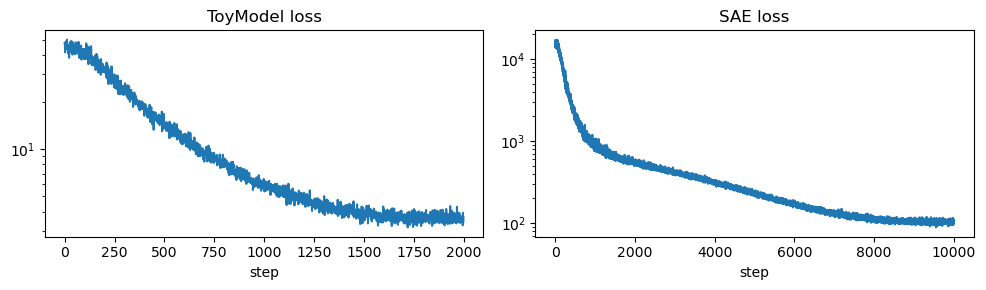

In [120]:
import matplotlib.pyplot as plt

D, F, d = 256, 20, 5
alpha, C = 1.0, 0.5

model = ToyModel(d, F, alpha, C)
model_losses = train_model(model, n_steps=2000, batch_size=D, lr=1e-3)


x_test = build_activations(1024, F, alpha, C)
h_test = model.hidden(x_test)

sae = VanillaSAE(d, h=40, alpha=alpha, C=C, l0=0.1)
sae_losses = train_sae(sae, model, n_steps=10000, n_eval_steps=2000, batch_size=D, lr=1e-3, h_test=h_test)

# evaluate EV on a held-out batch
with torch.no_grad():
    x_test = build_activations(1024, F, alpha, C)
    h_test = model.hidden(x_test)
    h_hat = sae(h_test)
    print(f"EV = {ev(h_test, h_hat).item():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].set_yscale("log")
axes[1].set_yscale("log")
axes[0].plot(model_losses); axes[0].set_title("ToyModel loss"); axes[0].set_xlabel("step")
axes[1].plot(sae_losses);   axes[1].set_title("SAE loss");      axes[1].set_xlabel("step")
plt.tight_layout(); plt.show()

$\alpha: 1 \rightarrow 0.2$

Step 2000: EV = 0.0085
Step 4000: EV = 0.4434
Step 6000: EV = 0.6630
Step 8000: EV = 0.8061
Step 10000: EV = 0.8699
Step 12000: EV = 0.9018
Step 14000: EV = 0.9273
Step 16000: EV = 0.9391
Step 18000: EV = 0.9433
Step 20000: EV = 0.9438
EV = 0.9423


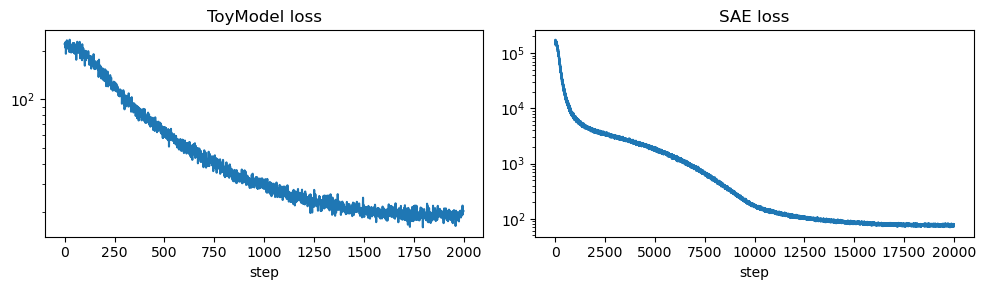

In [128]:
alpha = 0.2
l0 = 0.3

model = ToyModel(d, F, alpha, C)
model_losses = train_model(model, n_steps=2000, batch_size=D, lr=1e-3)


x_test = build_activations(1024, F, alpha, C)
h_test = model.hidden(x_test)

sae = VanillaSAE(d, h=40, alpha=alpha, C=C, l0=l0)
sae_losses = train_sae(sae, model, n_steps=20000, n_eval_steps=2000, batch_size=D, lr=1e-3, h_test=h_test)

# evaluate EV on a held-out batch
with torch.no_grad():
    x_test = build_activations(1024, F, alpha, C)
    h_test = model.hidden(x_test)
    h_hat = sae(h_test)
    print(f"EV = {ev(h_test, h_hat).item():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].set_yscale("log")
axes[1].set_yscale("log")
axes[0].plot(model_losses); axes[0].set_title("ToyModel loss"); axes[0].set_xlabel("step")
axes[1].plot(sae_losses);   axes[1].set_title("SAE loss");      axes[1].set_xlabel("step")
plt.tight_layout(); plt.show()

Кажется, в SAE можно и штраф побольше поставить.
Зависимости от $\alpha$ сильной не нашел, но наверно она есть.